# Development-only market data EDA

## TL;DR

- This notebook reads **development data only**. It never opens the sealed holdout.
- Development universe: **NQU6, ZTU6, ZNU6, CLU6, HGU6** (3,673 symbol-session rows).
- ES and GC are absent because their available observations fall inside the sealed period.
- The charts cover data availability, return behavior, volatility, and correlation. They are diagnostics—not a backtest.
- Current-contract filenames appear to contain historical continuation data. The vendor's roll/adjustment method must be confirmed before strategy simulation.


## Context & Methods

We are checking whether the current development sample is suitable for research and establishing a reproducible baseline. All statistics are descriptive and use session-level records produced from gap-aware one-minute bars.

### Key assumptions

- Session timestamps are interpreted using the workspace's configured futures session boundary.
- Missing minutes are not forward-filled.
- Features become available only at the recorded session close.
- The one-year holdout plus embargo remains inaccessible here.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

panel = pd.read_parquet(ROOT / "data/processed/research/development_session_panel.parquet")
features = pd.read_parquet(ROOT / "data/processed/features/development_session_features.parquet")
split = json.loads((ROOT / "data/catalog/temporal_split.json").read_text())
panel["trading_date"] = pd.to_datetime(panel["trading_date"])
assert panel["trading_date"].max() <= pd.Timestamp(split["development_end"])
print(f"Rows: {len(panel):,} | Symbols: {panel['symbol'].nunique()} | Last development date: {panel['trading_date'].max().date()}")
print(f"Complete feature rows: {features['feature_set_complete'].sum():,} / {len(features):,}")

Rows: 3,673 | Symbols: 5 | Last development date: 2025-08-15
Complete feature rows: 3,073 / 3,673


## Data

In [2]:
coverage = (panel.groupby("symbol").agg(
    first_session=("trading_date", "min"),
    last_session=("trading_date", "max"),
    sessions=("trading_date", "nunique"),
    median_minutes=("minute_observations", "median"),
    missing_minutes=("missing_minutes_inside_session", "sum"),
).sort_values("sessions", ascending=False))
coverage

,first_session,last_session,sessions,median_minutes,missing_minutes
symbol,,,,,
NQU6,2022-10-12,2025-08-15,735,1365.0,8601
ZTU6,2022-10-12,2025-08-15,735,1171.0,154265
ZNU6,2022-10-12,2025-08-15,735,1311.0,56305
CLU6,2022-10-12,2025-08-15,734,1370.0,9574
HGU6,2022-10-12,2025-08-15,734,1330.0,47784


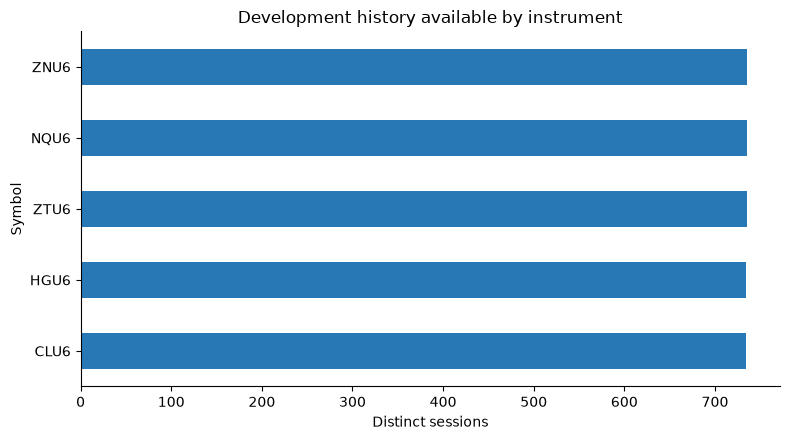

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
coverage.sort_values("sessions")["sessions"].plot.barh(ax=ax, color="#2878B5")
ax.set(title="Development history available by instrument", xlabel="Distinct sessions", ylabel="Symbol")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "eda_development_coverage.png", dpi=160)
plt.show()

## Results

In [4]:
returns = panel.pivot(index="trading_date", columns="symbol", values="close_to_close_return")
summary = returns.agg(["count", "mean", "std", "min", "max"]).T
summary["annualized_volatility"] = summary["std"] * np.sqrt(252)
summary

,count,mean,std,min,max,annualized_volatility
symbol,,,,,,
CLU6,733.0,0.000183,0.028616,-0.113443,0.107796,0.454267
HGU6,733.0,0.000305,0.015120,-0.172919,0.094445,0.240022
NQU6,734.0,0.000835,0.011752,-0.056638,0.115008,0.186552
ZNU6,734.0,-0.000037,0.004070,-0.012456,0.017094,0.064607
ZTU6,734.0,-0.000034,0.001396,-0.005268,0.011379,0.022168


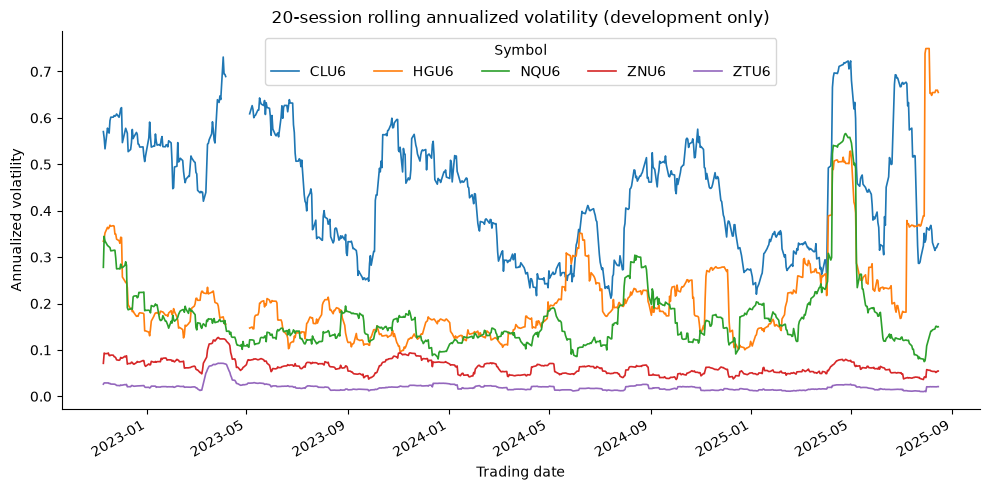

In [5]:
rolling_vol = returns.rolling(20, min_periods=20).std() * np.sqrt(252)
fig, ax = plt.subplots(figsize=(10, 5))
rolling_vol.plot(ax=ax, linewidth=1.2)
ax.set(title="20-session rolling annualized volatility (development only)", xlabel="Trading date", ylabel="Annualized volatility")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Symbol", ncol=5)
fig.tight_layout()
fig.savefig(OUT / "eda_development_volatility.png", dpi=160)
plt.show()

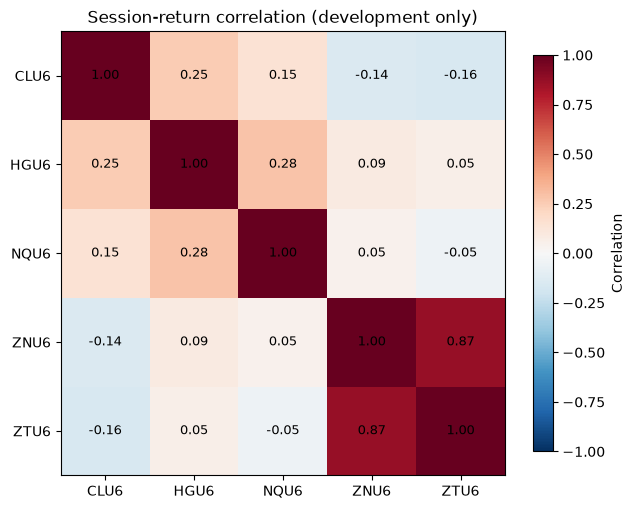

symbol,CLU6,HGU6,NQU6,ZNU6,ZTU6
symbol,,,,,
CLU6,1.000000,0.250692,0.146031,-0.143928,-0.160890
HGU6,0.250692,1.000000,0.282894,0.089508,0.054878
NQU6,0.146031,0.282894,1.000000,0.046626,-0.048787
ZNU6,-0.143928,0.089508,0.046626,1.000000,0.869838
ZTU6,-0.160890,0.054878,-0.048787,0.869838,1.000000


In [6]:
corr = returns.corr(min_periods=60)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns)
ax.set_yticks(range(len(corr)), corr.index)
for row in range(len(corr)):
    for col in range(len(corr)):
        value = corr.iloc[row, col]
        if pd.notna(value):
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Session-return correlation (development only)")
fig.colorbar(image, ax=ax, label="Correlation", shrink=0.8)
fig.tight_layout()
fig.savefig(OUT / "eda_development_correlation.png", dpi=160)
plt.show()
corr

## Takeaways

- CL, HG, NQ, ZN, and ZT have development histories long enough for the initial 60-session features.
- ES and GC cannot participate in feature research until older, pre-holdout observations are supplied.
- Missing-minute counts and unequal coverage remain explicit quality fields; no gaps are silently filled.
- Correlation is descriptive, not a promise of stable diversification or an instruction to trade.
- Next: review these diagnostics together, confirm continuation-series construction, then define point-in-time targets and the sequential simulator. No backtest has been run.
